In [1]:
# ============================================================
# CLUSTERING ANALYSIS
# Understanding and Implementing K-Means and DBSCAN Algorithms
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')


In [2]:
# -----------------------------
# Load Dataset
# -----------------------------
# Change file path if needed
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name='data')

# Display first 5 rows
print(df.head())


   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [3]:
# -----------------------------
# Dataset Information
# -----------------------------
print("\nShape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())




Shape of Dataset: (3999, 12)

Columns:
Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [4]:
# -----------------------------
# Data Preprocessing
# -----------------------------

# Remove ID column
df_clean = df.drop(['ID#'], axis=1)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Statistical Summary
print("\nStatistical Summary:")
print(df_clean.describe())



Statistical Summary:
            Balance    Qual_miles   cc1_miles    cc2_miles    cc3_miles  \
count  3.998000e+03   3998.000000  3998.00000  3998.000000  3998.000000   
mean   7.361949e+04    144.150575     2.05978     1.014507     1.012256   
std    1.007817e+05    773.757220     1.37699     0.147669     0.195265   
min    0.000000e+00      0.000000     1.00000     1.000000     1.000000   
25%    1.853425e+04      0.000000     1.00000     1.000000     1.000000   
50%    4.313800e+04      0.000000     1.00000     1.000000     1.000000   
75%    9.240500e+04      0.000000     3.00000     1.000000     1.000000   
max    1.704838e+06  11148.000000     5.00000     3.000000     5.000000   

         Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
count    3998.000000  3998.000000        3998.000000      3998.000000   
mean    17149.134567    11.604802         460.170835         1.373937   
std     24152.465996     9.603258        1400.365407         3.793585   
min       

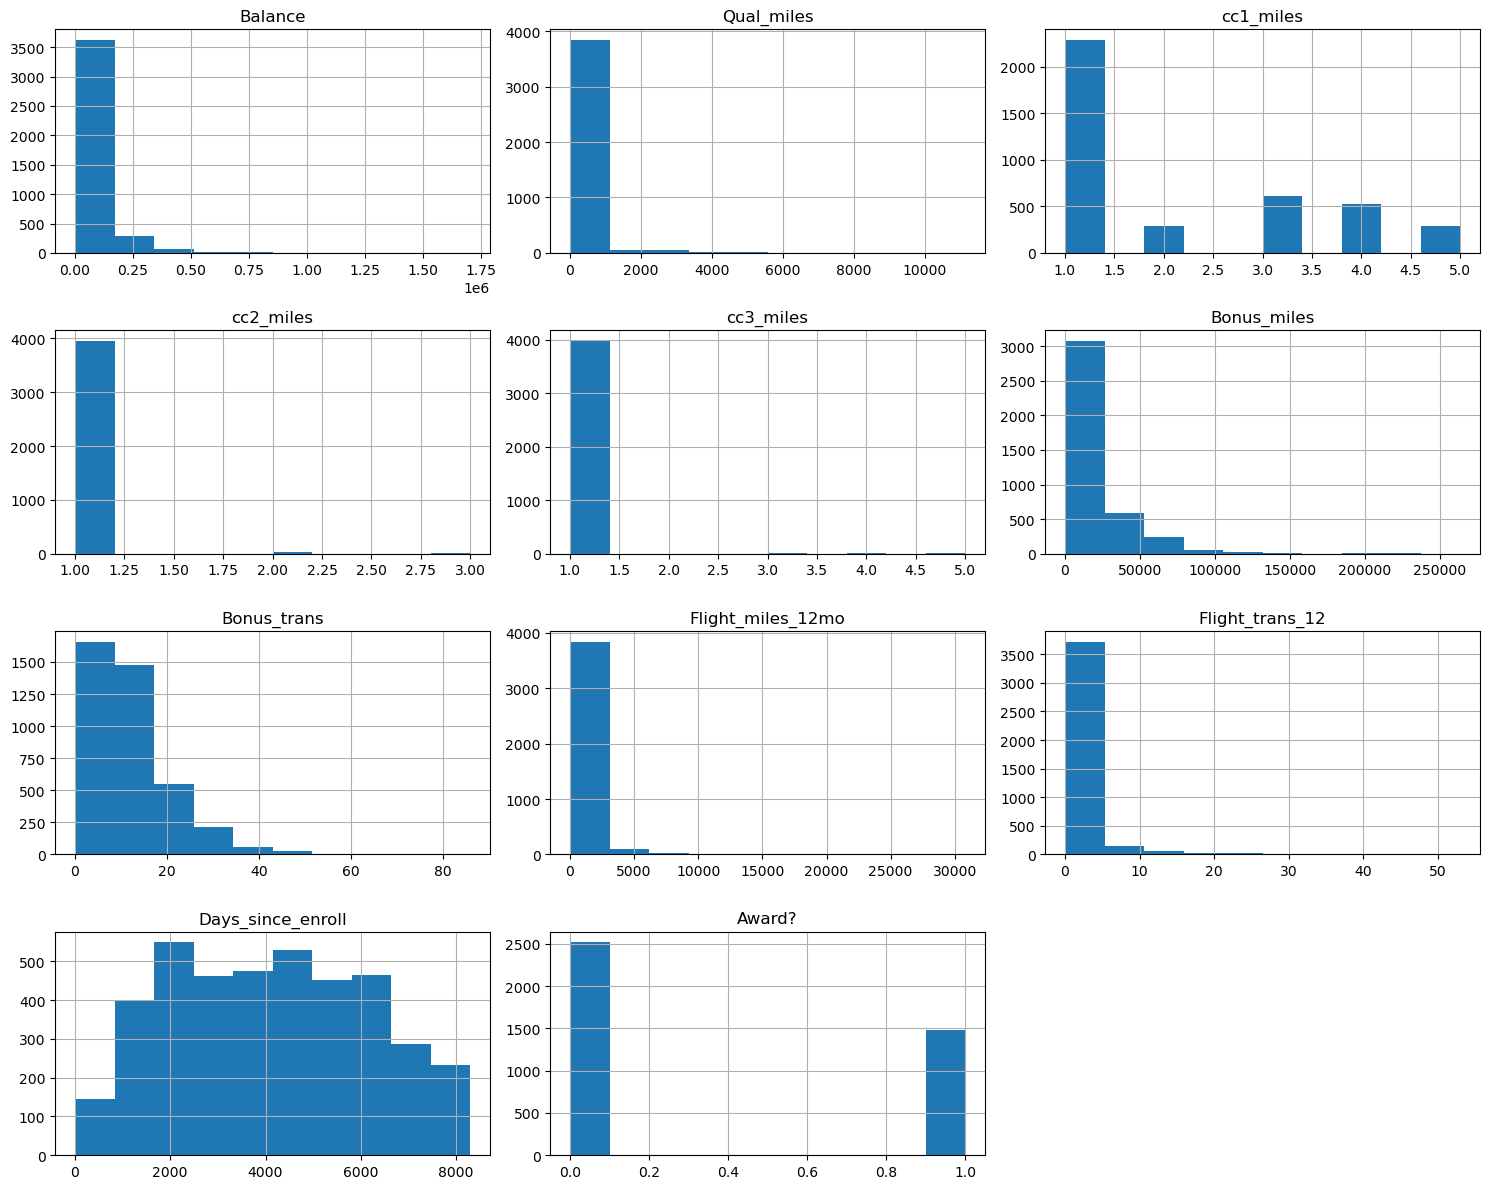

In [5]:
# -----------------------------
# Exploratory Data Analysis (EDA)
# -----------------------------

# Histograms
df_clean.hist(figsize=(15,12))
plt.tight_layout()
plt.show()


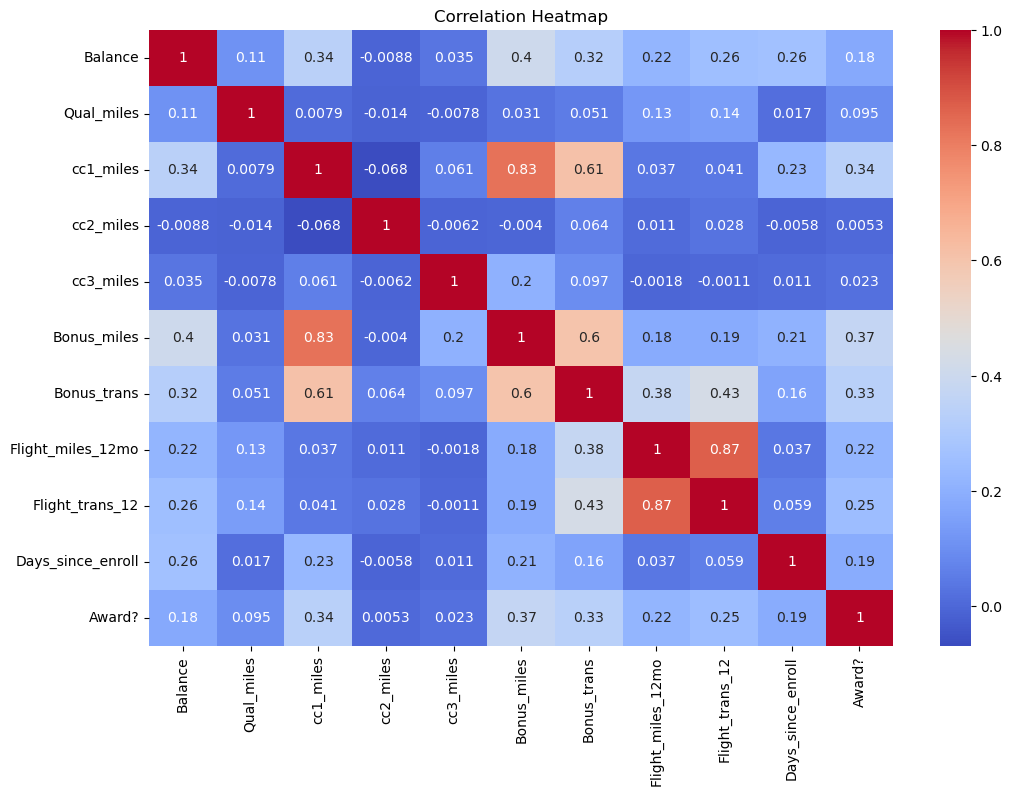

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

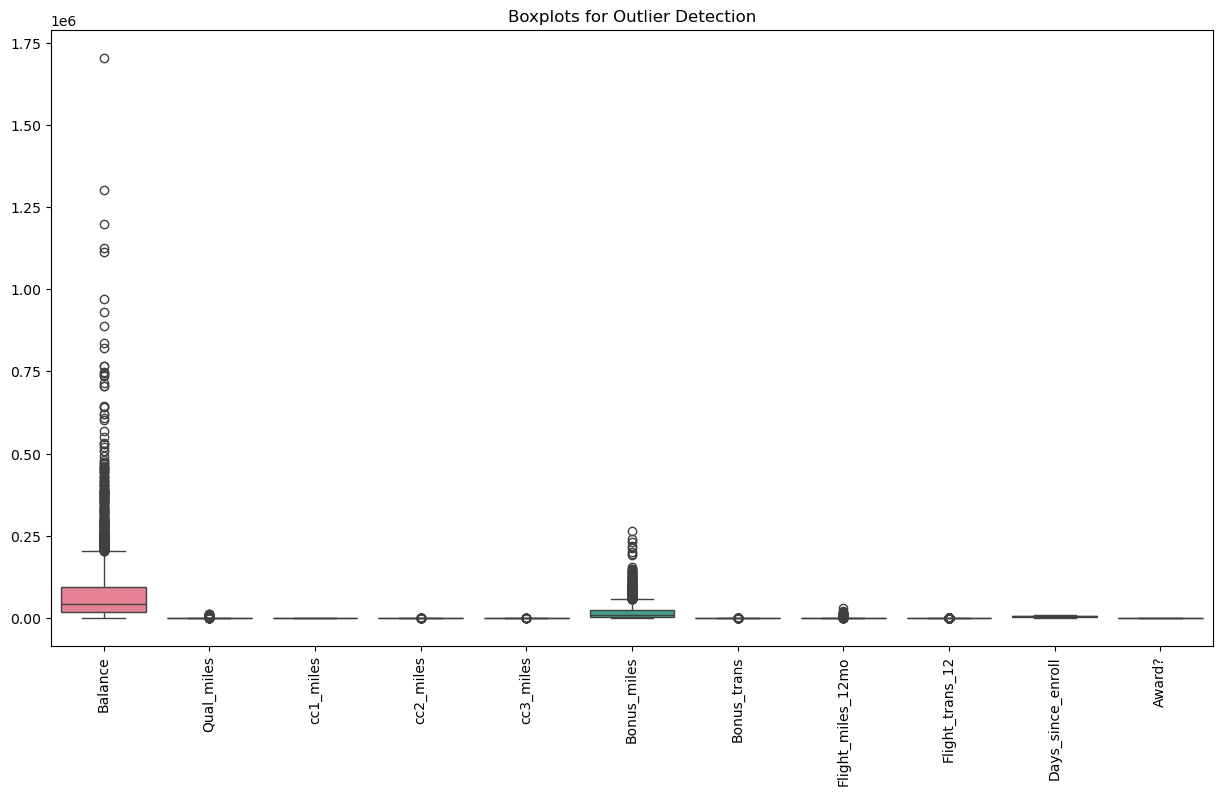

In [7]:
# Boxplots for Outlier Detection
plt.figure(figsize=(15,8))
sns.boxplot(data=df_clean)
plt.xticks(rotation=90)
plt.title("Boxplots for Outlier Detection")
plt.show()


In [8]:
# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(scaled_data, columns=df_clean.columns)

print("\nScaled Data:")
print(scaled_df.head())


Scaled Data:
    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.451294   -0.186323  -0.769732  -0.098254  -0.062774    -0.702920   
1 -0.539605   -0.186323  -0.769732  -0.098254  -0.062774    -0.701223   
2 -0.320192   -0.186323  -0.769732  -0.098254  -0.062774    -0.539397   
3 -0.583944   -0.186323  -0.769732  -0.098254  -0.062774    -0.689421   
4  0.239483   -0.186323   1.409207  -0.098254  -0.062774     1.082876   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
0    -1.104430          -0.328649        -0.362219           1.395235   
1    -1.000286          -0.328649        -0.362219           1.379736   
2    -0.791997          -0.328649        -0.362219           1.411702   
3    -1.104430          -0.328649        -0.362219           1.371987   
4     1.499179           1.154721         0.692324           1.363754   

     Award?  
0 -0.767072  
1 -0.767072  
2 -0.767072  
3 -0.767072  
4  1.303659  


In [9]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

# -----------------------------
# Elbow Method
# -----------------------------
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)


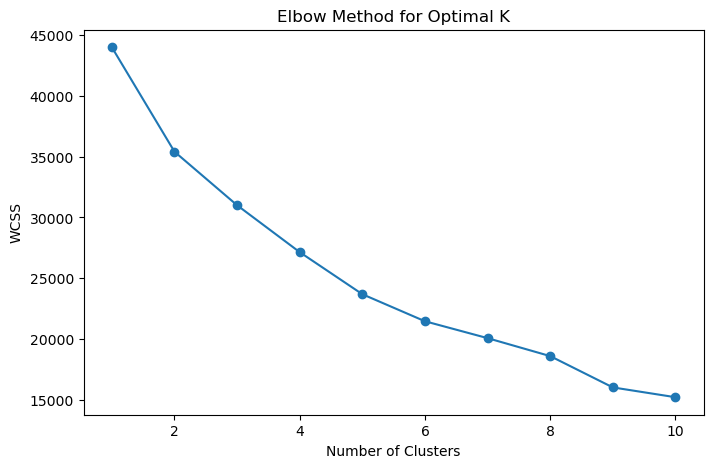

In [10]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [11]:
# -----------------------------
# Applying K-Means
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

# Add cluster labels
df_clean['KMeans_Cluster'] = kmeans_labels

# Silhouette Score
kmeans_score = silhouette_score(scaled_data, kmeans_labels)

print("\nK-Means Silhouette Score:", round(kmeans_score,3))



K-Means Silhouette Score: 0.308


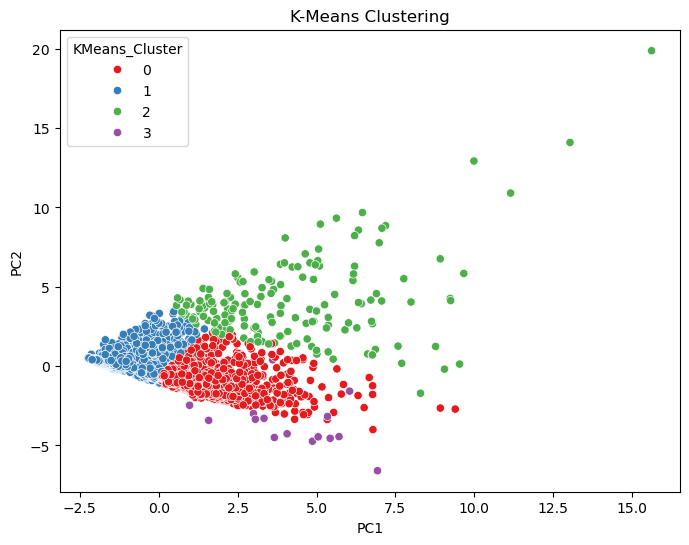

In [12]:
# -----------------------------
# PCA for Visualization
# -----------------------------
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])

pca_df['KMeans_Cluster'] = kmeans_labels

# Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='KMeans_Cluster',
                palette='Set1')

plt.title("K-Means Clustering")
plt.show()

In [15]:
# ============================================================
# DBSCAN CLUSTERING
# ============================================================

# -----------------------------
# Applying DBSCAN
# -----------------------------
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(scaled_data)

# Add cluster labels
df_clean['DBSCAN_Cluster'] = dbscan_labels

print("\nUnique DBSCAN Clusters:")
print(np.unique(dbscan_labels))

# -----------------------------
# Silhouette Score for DBSCAN
# -----------------------------
# Remove noise points (-1) before calculating score

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    
    dbscan_score = silhouette_score(
        scaled_data[mask],
        dbscan_labels[mask]
    )
    
    print("\nDBSCAN Silhouette Score:",
          round(dbscan_score,3))
    
else:
    print("\nSilhouette score cannot be calculated properly.")



Unique DBSCAN Clusters:
[-1  0  1  2  3  4]

DBSCAN Silhouette Score: 0.294


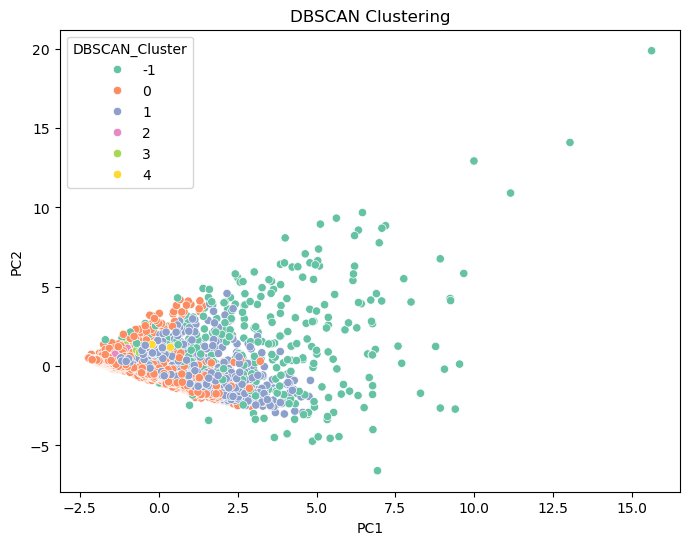

In [16]:
# -----------------------------
# DBSCAN Visualization
# -----------------------------
pca_df['DBSCAN_Cluster'] = dbscan_labels

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='DBSCAN_Cluster',
                palette='Set2')

plt.title("DBSCAN Clustering")
plt.show()

In [17]:
# ============================================================
# Cluster Interpretation
# ============================================================

print("\n================ CLUSTER ANALYSIS =================")

print("\nK-Means Insights:")
print("1. Customers are divided into groups based on flight activity.")
print("2. Some clusters represent frequent flyers with high bonus miles.")
print("3. Other clusters contain low-engagement customers.")

print("\nDBSCAN Insights:")
print("1. DBSCAN identifies dense regions and outliers.")
print("2. Noise points (-1) represent unusual customer behavior.")
print("3. DBSCAN handles irregular cluster shapes effectively.")

print("\nConclusion:")
print("K-Means created clearly separated clusters.")
print("DBSCAN successfully detected dense groups and outliers.")
print("Silhouette score was used to evaluate clustering quality.")


================ CLUSTER ANALYSIS =================

K-Means Insights:
1. Customers are divided into groups based on flight activity.
2. Some clusters represent frequent flyers with high bonus miles.
3. Other clusters contain low-engagement customers.

DBSCAN Insights:
1. DBSCAN identifies dense regions and outliers.
2. Noise points (-1) represent unusual customer behavior.
3. DBSCAN handles irregular cluster shapes effectively.

Conclusion:
K-Means created clearly separated clusters.
DBSCAN successfully detected dense groups and outliers.
Silhouette score was used to evaluate clustering quality.
